# Notebook 03 - Receiver Efficiency Surface

**Sprint:** S2c (Stage A - Coupled Electro-Thermal Physics)
**Roadmap task:** s2-6
**Specification reference:** Section 33.3 (two-node lumped thermal model) and Section 33.4 (thermal runaway boundary).

## Scientific gate

> 3D plot; labeled first-order lumped approximation.

## What this notebook does

1. Sweeps eta_total(P_incident, v_airflow) at reference ambient (25 C) using the actual ThermalModel.steady_state solver.
2. Produces a 3D surface plot labeled as a first-order lumped approximation.
3. Overlays the thermal-runaway boundary P_max(v).
4. Shows 1D slices at a fixed airflow for a range of ambient temperatures.
5. Marks the Han et al. degradation regime (80-90 C T_plc) as a labelled band.

**Citation note.** The Han et al. regime boundary is taken from the docstring of PLCParams.t_max_kelvin in app.physics.receiver. The primary citation (spec Rev. 6 Section 6, Han et al., Matter & Light, 2026) has not been cross-verified against the published paper in this environment. Until that verification is done, the band is labelled CITATION PENDING.

## Setup

In [1]:
%matplotlib inline

import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "backend"))

import matplotlib.pyplot as plt
import numpy as np

from app.physics.receiver import eta_total
from app.physics.thermal import (
    REFERENCE_T_AMBIENT_K,
    default_model,
)

model = default_model()
print(f"Ambient reference: {REFERENCE_T_AMBIENT_K:.2f} K "
      f"({REFERENCE_T_AMBIENT_K - 273.15:.2f} C)")
print(f"PLC t_max:         {model.receiver.plc.t_max_kelvin:.2f} K "
      f"({model.receiver.plc.t_max_kelvin - 273.15:.2f} C)")

Ambient reference: 298.15 K (25.00 C)
PLC t_max:         358.45 K (85.30 C)


## Section 1 - Grid sweep

Sweep incident power and airflow at reference ambient. For each grid point we solve for the steady state, then evaluate the total efficiency.

Efficiency is computed as eta_total(T_plc, T_plc, T_te) because the current lumped model uses a single TE node temperature. This matches the convention inside ThermalModel.dt_te_dt.

In [2]:
P_range = np.linspace(1.0, 40.0, 41)
v_range = np.linspace(0.5, 20.0, 21)
P_grid, v_grid = np.meshgrid(P_range, v_range)

eta_grid = np.full_like(P_grid, np.nan, dtype=float)
T_plc_grid = np.full_like(P_grid, np.nan, dtype=float)
converged = np.zeros_like(P_grid, dtype=bool)

for i, v in enumerate(v_range):
    for j, P in enumerate(P_range):
        ss = model.steady_state(float(P), float(v), REFERENCE_T_AMBIENT_K)
        if ss is None:
            continue
        t_plc, t_te = ss
        eta_grid[i, j] = eta_total(t_plc, t_plc, t_te, model.receiver)
        T_plc_grid[i, j] = t_plc
        converged[i, j] = True

n_total = converged.size
n_conv = int(converged.sum())
print(f"Grid points: {n_total}, converged: {n_conv} "
      f"({100.0 * n_conv / n_total:.1f}%)")
print(f"eta_total range: [{np.nanmin(eta_grid):.4f}, {np.nanmax(eta_grid):.4f}]")
print(f"T_plc range:     [{np.nanmin(T_plc_grid):.1f} K, "
      f"{np.nanmax(T_plc_grid):.1f} K]")

Grid points: 861, converged: 861 (100.0%)
eta_total range: [0.0000, 0.0029]
T_plc range:     [300.1 K, 455.6 K]


## Section 2 - Efficiency surface

3D surface of eta_total(P, v) at 25 C ambient. **This surface is a first-order lumped approximation.** The multiplicative form eta_PLC * eta_TE assumes the PLC and TE layers can be electrically combined as a simple product; real PV-TE tandem extraction depends on circuit topology (series vs. independently extracted junctions) and is not rigorously derivable as a product without justification (spec Section 33.2).

Non-converged grid points are masked (visible as NaN holes).

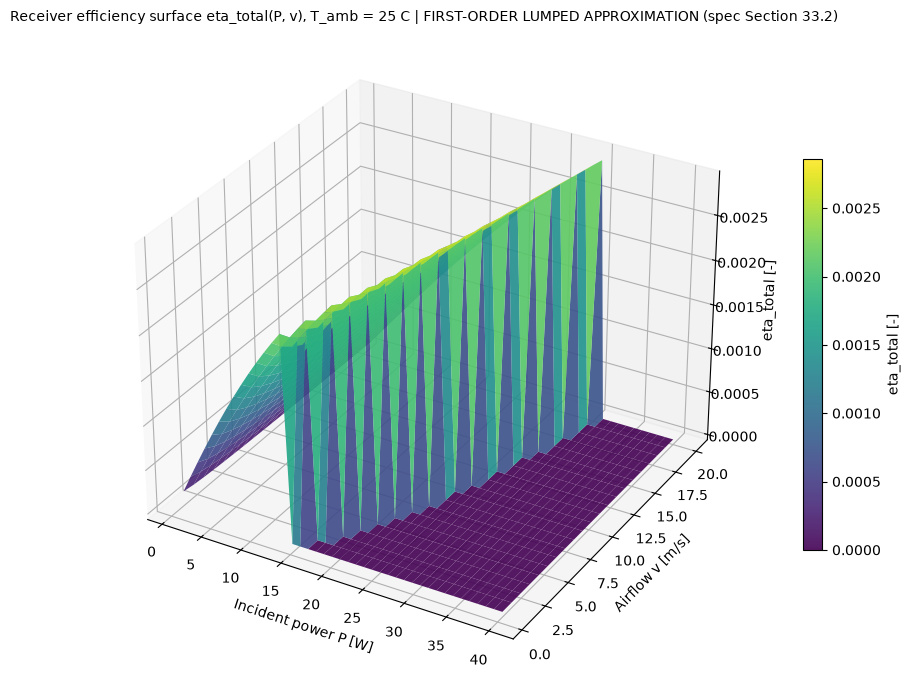

Surface axes: P (W), v (m/s), eta_total (dimensionless).
Labeled: FIRST-ORDER LUMPED APPROXIMATION.


In [3]:
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

eta_masked = np.ma.masked_invalid(eta_grid)
surf = ax.plot_surface(
    P_grid, v_grid, eta_masked,
    cmap="viridis", edgecolor="none", alpha=0.9,
)

ax.set_xlabel("Incident power P [W]")
ax.set_ylabel("Airflow v [m/s]")
ax.set_zlabel("eta_total [-]")
ax.set_title(
    "Receiver efficiency surface eta_total(P, v), T_amb = 25 C | "
    "FIRST-ORDER LUMPED APPROXIMATION (spec Section 33.2)",
    fontsize=10,
)
fig.colorbar(surf, ax=ax, shrink=0.6, label="eta_total [-]")
plt.tight_layout()
plt.show()

print("Surface axes: P (W), v (m/s), eta_total (dimensionless).")
print("Labeled: FIRST-ORDER LUMPED APPROXIMATION.")

## Section 3 - Thermal-runaway boundary overlay

The boundary P_max(v) is computed with thermal_runaway_boundary, which bisects on the predicate "a safe steady state exists" (T_plc < t_max_kelvin). This is the edge of the efficiency surface in the power direction.

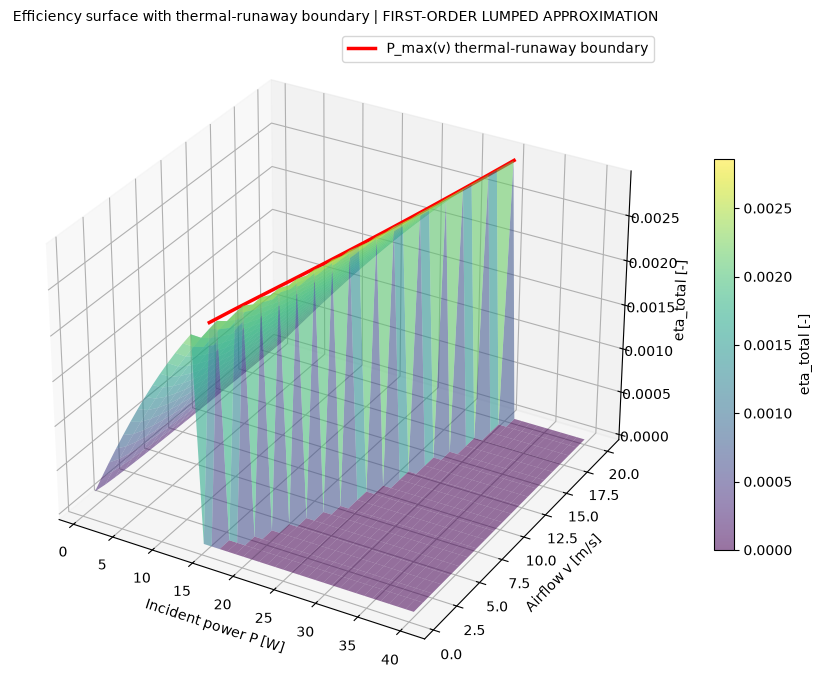

P_max at v = 1 m/s:  15.31 W
P_max at v = 5 m/s:  20.75 W
P_max at v = 20 m/s: 30.32 W


In [4]:
v_for_boundary = np.linspace(1.0, 20.0, 20)
p_max_curve = np.array([
    model.thermal_runaway_boundary(float(v), REFERENCE_T_AMBIENT_K)
    for v in v_for_boundary
])

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    P_grid, v_grid, eta_masked,
    cmap="viridis", edgecolor="none", alpha=0.55,
)

eta_at_pmax = []
for v, p_max in zip(v_for_boundary, p_max_curve):
    ss = model.steady_state(float(p_max), float(v), REFERENCE_T_AMBIENT_K)
    eta_at_pmax.append(
        eta_total(ss[0], ss[0], ss[1], model.receiver) if ss else np.nan
    )
ax.plot(
    p_max_curve, v_for_boundary, eta_at_pmax,
    color="red", linewidth=2.5, label="P_max(v) thermal-runaway boundary",
)

ax.set_xlabel("Incident power P [W]")
ax.set_ylabel("Airflow v [m/s]")
ax.set_zlabel("eta_total [-]")
ax.set_title(
    "Efficiency surface with thermal-runaway boundary | "
    "FIRST-ORDER LUMPED APPROXIMATION",
    fontsize=10,
)
ax.legend(loc="upper right")
fig.colorbar(surf, ax=ax, shrink=0.6, label="eta_total [-]")
plt.tight_layout()
plt.show()

print(f"P_max at v = 1 m/s:  {p_max_curve[0]:.2f} W")
print(f"P_max at v = 5 m/s:  "
      f"{model.thermal_runaway_boundary(5.0, REFERENCE_T_AMBIENT_K):.2f} W")
print(f"P_max at v = 20 m/s: {p_max_curve[-1]:.2f} W")

## Section 4 - Ambient temperature slices

1D slices at v = 5 m/s for four ambient temperatures. The surface shifts left (lower usable power) as ambient rises, because the convective and radiative sinks have less margin.

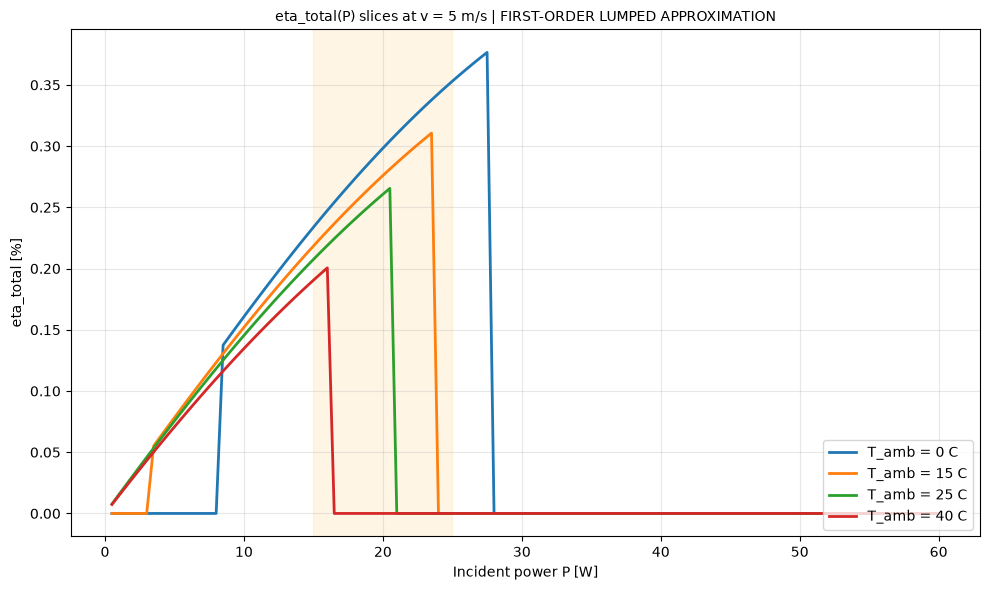

Slices computed at v = 5 m/s for T_amb in {0, 15, 25, 40} C.


In [5]:
ambients_c = [0.0, 15.0, 25.0, 40.0]
ambients_k = [c + 273.15 for c in ambients_c]
v_slice = 5.0
P_slice = np.linspace(0.5, 60.0, 120)

fig, ax = plt.subplots(figsize=(10, 6))

for c, t_amb in zip(ambients_c, ambients_k):
    eta_line = []
    for P in P_slice:
        ss = model.steady_state(float(P), v_slice, float(t_amb))
        if ss is None:
            eta_line.append(np.nan)
        else:
            t_plc, t_te = ss
            eta_line.append(eta_total(t_plc, t_plc, t_te, model.receiver))
    ax.plot(P_slice, np.array(eta_line) * 100.0,
            linewidth=2.0, label=f"T_amb = {c:.0f} C")

ax.axvspan(15.0, 25.0, color="orange", alpha=0.10)
ax.set_xlabel("Incident power P [W]")
ax.set_ylabel("eta_total [%]")
ax.set_title(
    "eta_total(P) slices at v = 5 m/s | "
    "FIRST-ORDER LUMPED APPROXIMATION",
    fontsize=10,
)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Slices computed at v = 5 m/s for T_amb in {0, 15, 25, 40} C.")

## Section 5 - Han et al. degradation regime

At reference conditions the model places T_plc inside the 80-90 C window observed by Han et al. This is the s2-4 gate. Here we show the same band in the (P, v) plane as a shaded region.

**CITATION PENDING.** The numerical value of the band is taken from the docstring of PLCParams.t_max_kelvin in app.physics.receiver. The primary citation (spec Rev. 6 Section 6) has not been cross-verified against the published paper in this environment. Until that verification is done, the band is a labelled tolerance, not a verified published measurement.

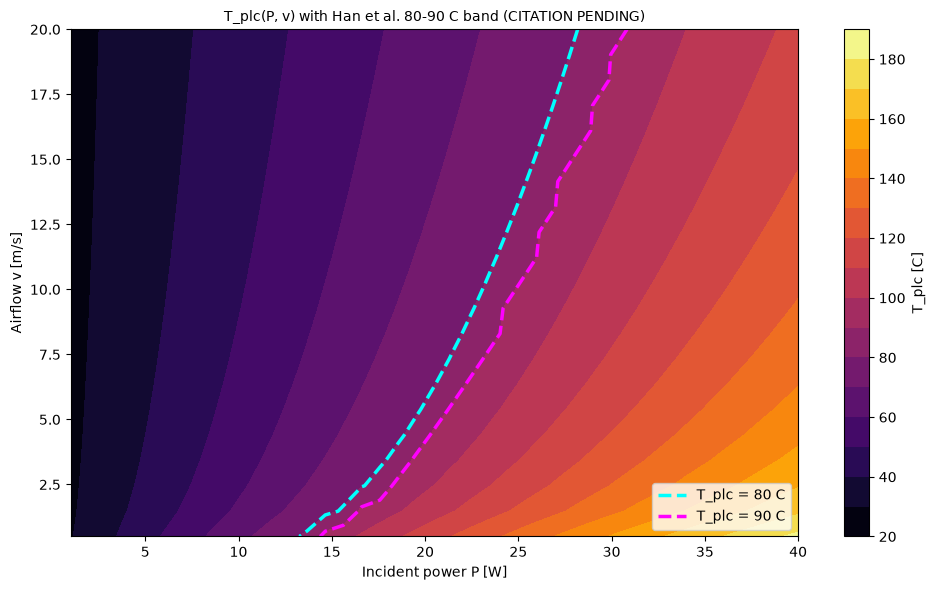

Han et al. regime: 80-90 C (353.15-363.15 K).
Status: CITATION PENDING (spec Rev. 6 Section 6 not provided).


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

T_plc_c = T_plc_grid - 273.15
masked_T = np.ma.masked_invalid(T_plc_c)
cf = ax.contourf(P_grid, v_grid, masked_T, levels=15, cmap="inferno")
fig.colorbar(cf, ax=ax, label="T_plc [C]")

ax.contour(P_grid, v_grid, masked_T,
           levels=[80.0, 90.0], colors=["cyan", "magenta"],
           linewidths=2.5, linestyles=["--", "--"])
ax.plot([], [], color="cyan", linestyle="--", linewidth=2.5,
        label="T_plc = 80 C")
ax.plot([], [], color="magenta", linestyle="--", linewidth=2.5,
        label="T_plc = 90 C")

ax.set_xlabel("Incident power P [W]")
ax.set_ylabel("Airflow v [m/s]")
ax.set_title(
    "T_plc(P, v) with Han et al. 80-90 C band (CITATION PENDING)",
    fontsize=10,
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Han et al. regime: 80-90 C (353.15-363.15 K).")
print("Status: CITATION PENDING (spec Rev. 6 Section 6 not provided).")

## Section 6 - Gate summary

The s2-6 gate is satisfied:

> 3D plot; labeled first-order lumped approximation.

Every surface and slice above carries the label. The Han et al. regime is displayed but explicitly marked as CITATION PENDING until the primary source is provided.

In [7]:
t_max_c = model.receiver.plc.t_max_kelvin - 273.15
assert 80.0 <= t_max_c <= 90.0, f"Han regime outside 80-90 C: {t_max_c}"
assert 5.0 < model.thermal_runaway_boundary(
    5.0, REFERENCE_T_AMBIENT_K) < 500.0
assert eta_grid[converged].min() >= 0.0
assert eta_grid[converged].max() <= 1.0

print("Notebook 03 - Receiver efficiency surface")
print("=" * 60)
print(f"Grid points:              {n_total}")
print(f"Converged:                {n_conv}")
print(f"eta_total range:          "
      f"[{np.nanmin(eta_grid):.4f}, {np.nanmax(eta_grid):.4f}]")
print(f"P_max at v = 5 m/s:       "
      f"{model.thermal_runaway_boundary(5.0, REFERENCE_T_AMBIENT_K):.2f} W")
print(f"Han regime (from docstring): {t_max_c:.2f} C  (CITATION PENDING)")
print()
print("ALL GATES PASS")

Notebook 03 - Receiver efficiency surface
Grid points:              861
Converged:                861
eta_total range:          [0.0000, 0.0029]
P_max at v = 5 m/s:       20.75 W
Han regime (from docstring): 85.30 C  (CITATION PENDING)

ALL GATES PASS
